# Funzioni polinomiali in SageMath



## Definizione di una funzione polinomiale

Iniziamo definendo la seguente funzione polinomiale di secondo grado: 
$$f(x)=x^3+2x^2-3x$$


In [1]:
x=var('x')  # questo comando definisce x come variabile simbolica
f(x)=x^3+2*x^2-3*x

In questa maniera abbiamo definito la funzione $f$ nella variabile $x$. Sage considera già la lettera `x` come una variabile simbolica, ma meglio ripeterlo.

Vediamo cos'è `f`:

In [2]:
f

x |--> x^3 + 2*x^2 - 3*x

Questo ci dice che Sage considera `f` come un'espressione simbolica, in questo caso definita proprio come la funzione polinomiale $f(x)=x^3+2x^2-3x$ 

Possiamo ottenere un formato in output più elegante con il comando `%display latex`

In [3]:
%display latex
f(x)

x^3 + 2*x^2 - 3*x

Per tornare al formato originale usiamo `%display play`:

In [4]:
%display plain
f

x |--> x^3 + 2*x^2 - 3*x

Valutiamo $f$ per alcuni valori di $x$, ad esempio, $x=0$

In [7]:
f(2)

10

Una maniera veloce per valutare una funzione su un elenco di valori è quello di creare una lista con i valori che ci interessano e usare il comando `map`.

Creiamo la lista: $[0, -0.5,-1/2,\sqrt{2},-3,-2]$

In [8]:
xval=[0,-0.5,-1/2,sqrt(2),-2,-3,2]   #questo comando crea una lista
xval

[0, -0.500000000000000, -1/2, sqrt(2), -2, -3, 2]

`map` calcola: $f(0), f(-0.5),f(-1/2),\dots$

In [9]:
%display latex
yval=list(map(f,xval))  #list crea una lista sul risultato di map
yval

[0, 1.87500000000000, 15/8, -sqrt(2) + 4, 6, 0, 10]

## Operazioni tra i polinomi

Consideriamo i due polinomi visti in classe e rivediamo le operazioni tra i polinomi in Sage

In [10]:
p(x)=3*x^3+1/2*x+1
g(x)=-x^2+2*x
show('p(x)=',p(x))
show('g(x)=',g(x))

'p(x)=' 3*x^3 + 1/2*x + 1

'g(x)=' -x^2 + 2*x

In [11]:
p+g # addizione

x |--> 3*x^3 - x^2 + 5/2*x + 1

In [12]:
a=3
a*p # moltiplicazione per scalare

x |--> 9*x^3 + 3/2*x + 3

In [13]:
show('p(x)=',p(x))
show('g(x)=',g(x))
h=p*g
show('p(x)*g(x)=',h(x)) # moltiplicazione tra polinomi

'p(x)=' 3*x^3 + 1/2*x + 1

'g(x)=' -x^2 + 2*x

'p(x)*g(x)=' -1/2*(6*x^3 + x + 2)*(x^2 - 2*x)

In [14]:
expand(h(x)) # expand svolge le moltiplicazioni

-3*x^5 + 6*x^4 - 1/2*x^3 + 2*x

Per fare la **divisione polinomiale** bisogna usare un *metodo*. Ricordiamo che dividere $P(x)$ per $D(x)$ significa trovare i polinomi quoziente, $Q(x)$, e resto, $R(x)$ tali che:

$$P(x)=Q(x)\cdot D(x)+R(x)$$

con $R(x)$ che ha grado minore o uguale a $D(x)$. Facciamo un esempio:

In [15]:
P(x)=2*x^3-x+1
D(x)=-x^2+2*x
show('P(x)=',P(x))
show('D(x)=',D(x))


'P(x)=' 2*x^3 - x + 1

'D(x)=' -x^2 + 2*x

In [16]:
[Q,R]=P.maxima_methods().divide(D) #divisione con resto
show('Q(x)=',Q)
show('R(x)=',R)

'Q(x)=' -2*x - 4

'R(x)=' 7*x + 1

Verifichiamo che $D\cdot Q+R=P$:

In [17]:
D*Q+R

x |--> 2*(x^2 - 2*x)*(x + 2) + 7*x + 1

In [18]:
expand(D*Q+R)

x |--> 2*x^3 - x + 1

Questo comando va bene anche per verificare i nostri conti con il metodo di Ruffini.

Ad esempio, $P(x)=2x^3-x+1$, $P(-1)=0$, quindi $D(x)=x+1$ deve dividere esattamente $P$:

In [19]:
show('P(-1)=',P(-1))

'P(-1)=' 0

In [20]:
D(x)=x+1
[Q,R]=P.maxima_methods().divide(D) #divisione con resto
show('Q(x)=',Q)
show('R(x)=',R)

'Q(x)=' 2*x^2 - 2*x + 1

'R(x)=' 0

## Grafico di una funzione

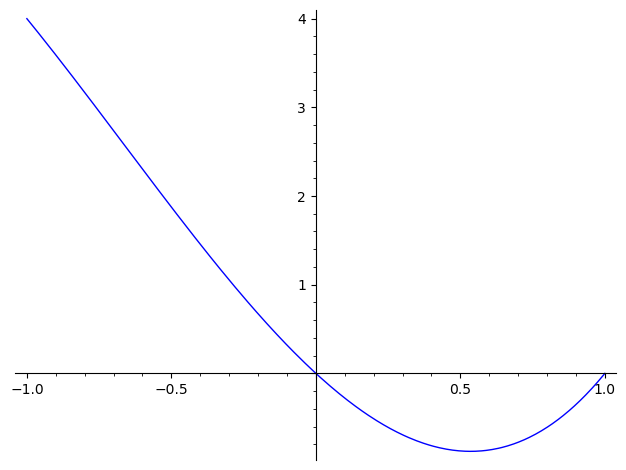

In [21]:
plot(f) 

Il grafico viene creato di defoult per $x\in [-1,1]$. Cambiamo gli estremi usando `xmin` e `xmax`. Cambiamo colore, inseriamo la legenda e battezziamo gli assi.

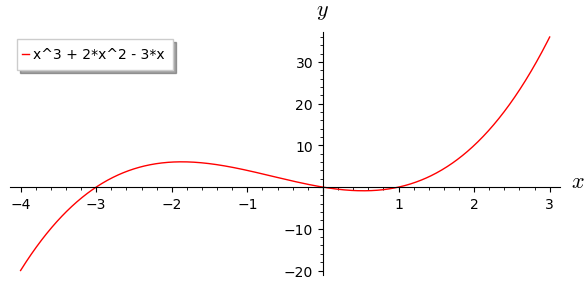

In [22]:
plot_f=plot(f,xmin=-4,xmax=3,color='red',legend_label=f(x),axes_labels=['$x$', '$y$']            )
show(plot_f,figsize=[6,3])

Vogliamo mostrare sul grafico i punti calcolati, `xval` e `yval`. 

Possiamo usare il comando `list_plot` per fare il grafico di punti. Ecco un esempio:

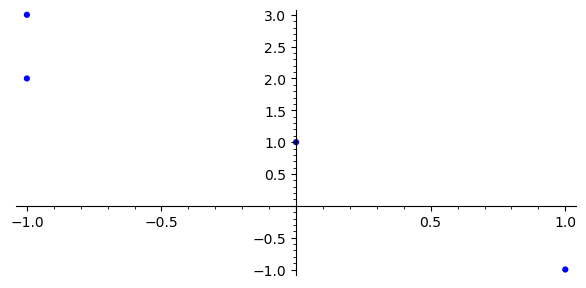

In [23]:
list_plot([[0,1],[1,-1],[-1,3],[-1,2]],size=20,figsize=[6,3]) # list_plot riceve in input una lista di coordinate

Prima di usare `list_plot` sui punti trovati `xval` e `yval`, dobbiamo riorganizzarli in modo da avere una lista del tipo $[(x_1,y_1),(x_2,y_2),\dots]$. Si usa il comando `zip`

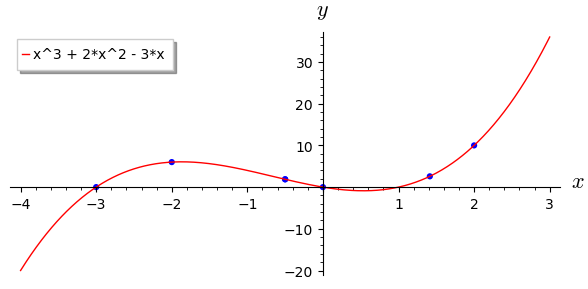

In [24]:
punti = list(zip(xval, yval))  
plot_p=list_plot(punti,size=20)
show(plot_p+plot_f,figsize=[6,3]) # questo mostra insieme i due grafici gia' creati